# Daily Challenge: Classifying Handwritten Digits with CNNs


## 👩‍🏫 👩🏿‍🏫 What You’ll learn
- How to load and preprocess the MNIST dataset.
- How to build a basic Fully Connected Neural Network for image classification.
- How to build and train a Convolutional Neural Network (CNN) for image classification.
- Understanding the impact of different network architectures on performance.
- Basic Keras functionalities for model building and training.


## 🛠️ What you will create
You will create two models:

1. A Fully Connected Neural Network (Dense layers) to classify handwritten digits from the MNIST dataset.
2. A Convolutional Neural Network (CNN) to classify handwritten digits from the MNIST dataset, and compare its performance with the first model.


## What You Need to Do
1. **Load the MNIST dataset**:

    - Use keras.datasets.mnist.load_data() to load the training and testing data.
    - Print the shapes of the loaded data to understand the dataset structure.

2. **Preprocess the data for a Fully Connected Neural Network**:

    - Flatten the images from 28x28 to 784 pixels.
    - Normalize the pixel values by dividing by 255.
    - One-hot encode the target labels using keras.utils.np_utils.to_categorical().

3. **Build and train a Fully Connected Neural Network**:

    - Create a Sequential model.
    - Add Dense layers with appropriate activation functions (e.g., ReLU and softmax).
    - Compile the model with an optimizer (e.g., Adam), loss function (e.g., categorical cross-entropy), and metrics (e.g., accuracy).
    - Train the model using model.fit() and evaluate its performance.

4. **Preprocess the data for a Convolutional Neural Network**:

    - Reshape the input data to the shape expected by a Conv2D layer (e.g., (60000, 28, 28, 1)).
    - Normalize the pixel values by dividing by 255.
    - One-hot encode the target labels using keras.utils.np_utils.to_categorical().

5. **Build and train a Convolutional Neural Network**:

    - Create a Sequential model.
    - Add Conv2D and MaxPool2D layers.
    - Add a Flatten layer.
    - Add Dense layers with appropriate activation functions.
    - Compile and train the model, similar to the Fully Connected Neural Network.

6. **Compare the performance**:

    - Analyze the accuracy of both models.
    - Observe the difference between the Fully connected model and the CNN model.


In [3]:
# Step 1

from tensorflow import keras

# Load MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Print shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [5]:
#  inspect one image
print(X_train[0])
print("Label:", y_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

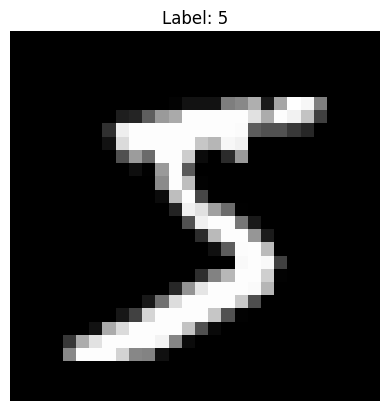

In [6]:
import matplotlib.pyplot as plt

# display the first image
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [10]:
# Step 2

from tensorflow.keras.utils import to_categorical

# Flatten images
X_train_flat = X_train.reshape(60000, 784)
X_test_flat = X_test.reshape(10000, 784)

# Normalize pixel values
X_train_flat = X_train_flat.astype("float32") / 255
X_test_flat = X_test_flat.astype("float32") / 255

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Check results
print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape:", X_test_flat.shape)
print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)
print("First label:", y_train[0])
print("One-hot version:", y_train_cat[0])

X_train_flat shape: (60000, 784)
X_test_flat shape: (10000, 784)
y_train_cat shape: (60000, 10)
y_test_cat shape: (10000, 10)
First label: 5
One-hot version: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [11]:
# Step 3

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build model
fc_model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile model
fc_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
fc_model.summary()

# Train model
history_fc = fc_model.fit(
    X_train_flat,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# Evaluate on test set
test_loss_fc, test_acc_fc = fc_model.evaluate(X_test_flat, y_test_cat)

print("Test loss:", test_loss_fc)
print("Test accuracy:", test_acc_fc)

/opt/miniconda3/envs/di-genai/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 709us/step - accuracy: 0.9216 - loss: 0.2708 - val_accuracy: 0.9572 - val_loss: 0.1469
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 639us/step - accuracy: 0.9672 - loss: 0.1103 - val_accuracy: 0.9665 - val_loss: 0.1104
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 751us/step - accuracy: 0.9765 - loss: 0.0764 - val_accuracy: 0.9679 - val_loss: 0.1085
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 623us/step - accuracy: 0.9820 - loss: 0.0569 - val_accuracy: 0.9732 - val_loss: 0.0878
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 669us/step - accuracy: 0.9856 - loss: 0.0442 - val_accuracy: 0.9744 - val_loss: 0.0994
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 628us/step - accuracy: 0.9889 - loss: 0.0358 - val_accuracy: 0.9747 - val_loss: 0.0971
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 624us/step - accuracy: 0.9896 - loss: 0.0312 - val_accuracy: 0.9751 - val_loss: 0.0949
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 627us/step - accuracy: 0.9931 -

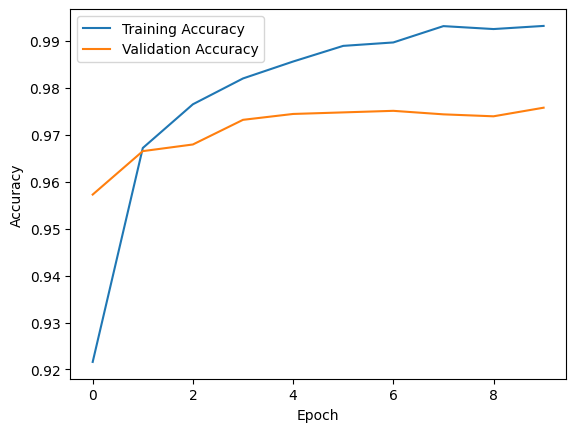

In [ ]:
import matplotlib.pyplot as plt

#  plot training history
plt.plot(history_fc.history['accuracy'], label='Training Accuracy')
plt.plot(history_fc.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

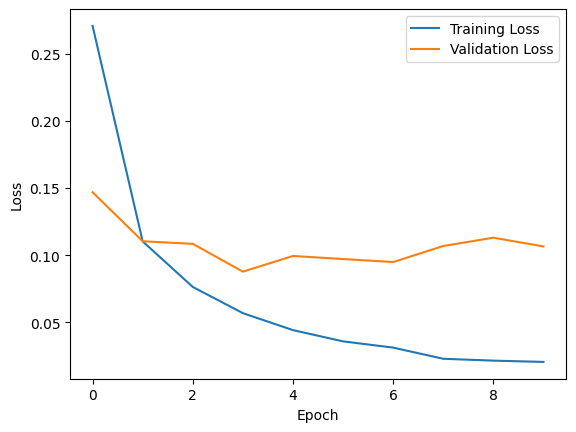

In [13]:
plt.plot(history_fc.history['loss'], label='Training Loss')
plt.plot(history_fc.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Step 4

# Reshape for CNN
X_train_cnn = X_train.reshape(60000, 28, 28, 1)
X_test_cnn = X_test.reshape(10000, 28, 28, 1)

# Normalize
X_train_cnn = X_train_cnn.astype("float32") / 255
X_test_cnn = X_test_cnn.astype("float32") / 255

# Labels can reuse previous one-hot encoding
# y_train_cat and y_test_cat already exist from step 2

# Check shapes
print("X_train_cnn shape:", X_train_cnn.shape)
print("X_test_cnn shape:", X_test_cnn.shape)
print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

X_train_cnn shape: (60000, 28, 28, 1)
X_test_cnn shape: (10000, 28, 28, 1)
y_train_cat shape: (60000, 10)
y_test_cat shape: (10000, 10)


In [15]:
# Step 5

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Build CNN model
cnn_model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile model
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show summary
cnn_model.summary()

# Train model
history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# Evaluate on test set
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(X_test_cnn, y_test_cat)

print("CNN Test loss:", test_loss_cnn)
print("CNN Test accuracy:", test_acc_cnn)

/opt/miniconda3/envs/di-genai/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9486 - loss: 0.1676 - val_accuracy: 0.9802 - val_loss: 0.0711
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9830 - loss: 0.0545 - val_accuracy: 0.9847 - val_loss: 0.0522
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9882 - loss: 0.0383 - val_accuracy: 0.9871 - val_loss: 0.0439
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9918 - loss: 0.0275 - val_accuracy: 0.9862 - val_loss: 0.0466
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9933 - loss: 0.0218 - val_accuracy: 0.9818 - val_loss: 0.0640
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9945 - loss: 0.0167 - val_accuracy: 0.9881 - val_loss: 0.0437
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9955 - loss: 0.0131 - val_accuracy: 0.9892 - val_loss: 0.0382
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9964 - loss: 0.0113 - 

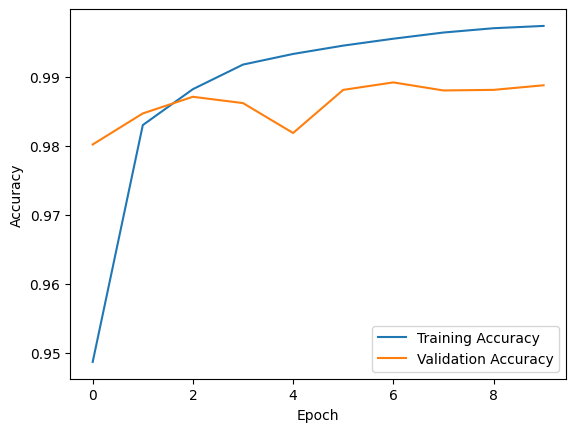

In [ ]:
# plot CNN accuracy

plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

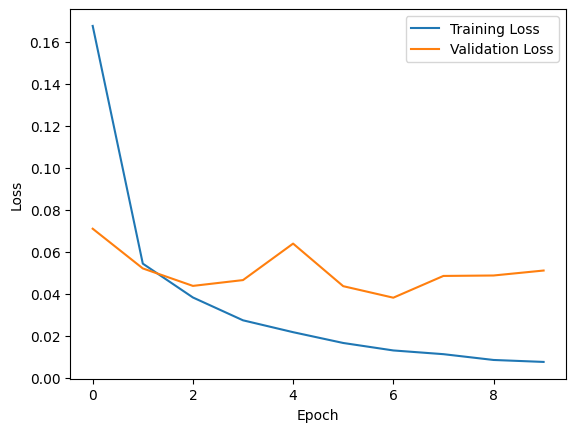

In [17]:
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [19]:
# Step 6

print("Fully Connected Test Accuracy:", test_acc_fc)
print("CNN Test Accuracy:", test_acc_cnn)

print(f"Fully Connected Test Accuracy: {test_acc_fc * 100:.2f}%")
print(f"CNN Test Accuracy: {test_acc_cnn * 100:.2f}%")
print()

if test_acc_cnn > test_acc_fc:
    print("The CNN performed better than the Fully Connected Neural Network.")
elif test_acc_cnn < test_acc_fc:
    print("The Fully Connected Neural Network performed better than the CNN.")
else:
    print("Both models performed equally.")

Fully Connected Test Accuracy: 0.9785000085830688
CNN Test Accuracy: 0.991100013256073
Fully Connected Test Accuracy: 97.85%
CNN Test Accuracy: 99.11%

The CNN performed better than the Fully Connected Neural Network.


**Comparison Summary**:

The Fully Connected Neural Network achieved good performance on the MNIST dataset,
but the Convolutional Neural Network performed better.

The main reason is that the fully connected model treats each image as a flat vector,
so it loses the spatial relationships between pixels. In contrast, the CNN preserves
the 2D image structure and learns local visual patterns such as edges, curves, and
shapes. This makes CNNs more effective for image classification tasks.

In conclusion, while both models can classify handwritten digits successfully, the CNN
is better suited for this problem and usually achieves higher accuracy.